In [1]:
%%time
# ── Global Parameters ──────────────────────────────────────
# All tunable constants in one place so cells can be run in any order.

EXIT_PLANES = 30          # exit planes for self-consistency plots
sampling = 0.1            # Å/pixel
slice_thickness = 0.4     # Å/slice

ORDERS = [1, 2, 3, 4, 6]                     # expansion orders for forward sweep
BSC_ORDERS = [2, 3, 4, 6]                    # order=1 diverges with full scope
FP_ORDER = 3                                  # expansion order for frozen phonon runs

print(f"ORDERS = {ORDERS}")
print(f"BSC_ORDERS = {BSC_ORDERS}")
print(f"FP_ORDER = {FP_ORDER}")
print(f"sampling = {sampling} Å/px, slice_thickness = {slice_thickness} Å")

ORDERS = [1, 2, 3, 4, 6]
BSC_ORDERS = [2, 3, 4, 6]
FP_ORDER = 3
sampling = 0.1 Å/px, slice_thickness = 0.4 Å
CPU times: total: 0 ns
Wall time: 298 μs


# DEV Real-Space Multislice: HRTEM Simulation at 30 keV

This notebook demonstrates HRTEM simulation using **DEV branch's real-space multislice**
with `expansion_scope="full"` (fully-corrected operator) and `return_backscattered=True`
(backscattered wave accumulation + back-propagation).

**Comparison**: Fourier multislice (reference) vs DEV fully_corrected at different expansion orders.

## Contents
1. Setup and crystal structure
2. Reference: Fourier multislice HRTEM
3. DEV fully_corrected forward scattering (order sweep)
4. DEV fully_corrected + BSC (with backscattering)
5. Exit wave comparison (order convergence, Fourier vs DEV)
6. Self-consistency verification (intensity, BSC depth, energy budget)
7. CTF application and HRTEM image formation
8. Frozen phonon HRTEM
9. Backscattering diffraction
10. BSC depth profile analysis
11. Summary

In [2]:
%%time
import sys, os

# Ensure the abTEM repo root is on sys.path so `test_cvdms` is importable.
# Walk up from CWD until we find the abtem package directory.
_repo_root = os.getcwd()
while _repo_root and not os.path.exists(os.path.join(_repo_root, "abtem", "__init__.py")):
    _parent = os.path.dirname(_repo_root)
    if _parent == _repo_root:  # reached filesystem root
        _repo_root = None
        break
    _repo_root = _parent

# Fallback: infer from the installed abtem package location (editable install)
if _repo_root is None:
    import abtem  # noqa: F811 — first import to find its path
    _abtem_file = abtem.__file__
    _candidate = os.path.dirname(os.path.dirname(_abtem_file))
    # Verify it contains test_cvdms before using it
    if os.path.isdir(os.path.join(_candidate, "test_cvdms")):
        _repo_root = _candidate
    del _abtem_file, _candidate

if _repo_root and _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)
del _repo_root

import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt
from ase.spacegroup import crystal
from abtem import PlaneWave, Potential, CTF, FrozenPhonons, Waves, show_atoms
from abtem.multislice import RealSpaceMultislice, FourierMultislice
from abtem.core import config

# CPU-only for broad compatibility
config.set({"device": "cpu", "fft": "fftw"})

print(f"abTEM version: {abtem.__version__}")
print(f"Device: {config.get('device')}")

abTEM version: 1.1.0
Device: cpu
CPU times: total: 2.19 s
Wall time: 2.32 s


## 1. Crystal Structure

SrTiO₃ [001], spacegroup 221 (Pm-3m), a = 3.905 Å.

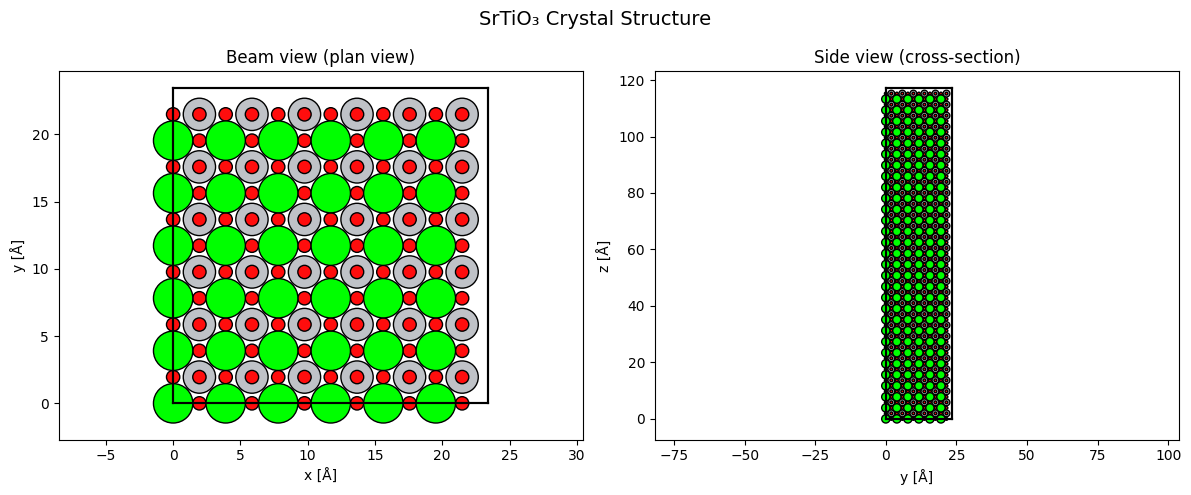

CPU times: total: 250 ms
Wall time: 288 ms


In [3]:
%%time
atoms = crystal(
    ["Sr", "Ti", "O"],
    basis=[(0, 0, 0), (0.5, 0.5, 0.5), (0.5, 0.5, 0)],
    spacegroup=221,
    cellpar=[3.905, 3.905, 3.905, 90, 90, 90],
)
atoms *= (6, 6, 30)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
show_atoms(atoms, plane="xy", ax=ax1, title="Beam view (plan view)")
show_atoms(atoms, plane="yz", ax=ax2, title="Side view (cross-section)")
fig.suptitle("SrTiO₃ Crystal Structure", fontsize=14)
plt.tight_layout()
plt.show()

## 2. Potential Setup

30 keV is the most challenging energy for convergence — large interaction parameter
σ, strong BSC effects.  We use fine slices (0.4 Å) to ensure convergence.

In [4]:
%%time
# Frozen phonons for thermal averaging
frozen_phonons = FrozenPhonons(atoms, num_configs=8, sigmas=0.085)

potential_fp = Potential(
    frozen_phonons,
    sampling=sampling,
    slice_thickness=slice_thickness,
    exit_planes=EXIT_PLANES,
    projection="finite",
)

# Single-configuration potential for quick tests
potential = Potential(
    atoms,
    sampling=sampling,
    slice_thickness=slice_thickness,
    exit_planes=EXIT_PLANES,
    projection="finite",
)

num_slices = len(potential)
print(f"Total slices: {num_slices}")
print(f"Exit planes: {potential.num_exit_planes}")
print(f"Total thickness: {num_slices * slice_thickness:.1f} Å")
print(f"FP configurations: {frozen_phonons.num_configs}")

Total slices: 293
Exit planes: 11
Total thickness: 117.2 Å
FP configurations: 8
CPU times: total: 31.2 ms
Wall time: 2.23 ms


## 3. Plane Wave Setup

30 keV plane wave illumination.

In [5]:
%%time
plane_wave = PlaneWave(energy=30e3)
print(f"Energy: {plane_wave.energy:.0f} eV")
print(f"Wavelength: {plane_wave.wavelength:.4f} Å")

Energy: 30000 eV
Wavelength: 0.0698 Å
CPU times: total: 0 ns
Wall time: 322 μs


## 4. Reference: Fourier Multislice

Standard Fourier split-step method as ground-truth reference.

In [6]:
%%time
print("Computing Fourier reference...")
exit_wave_fourier = plane_wave.multislice(
    potential,
    algorithm=FourierMultislice(order=1),
    lazy=False,
)
print(f"Exit wave shape: {exit_wave_fourier.shape}")
print(f"Exit wave dtype: {exit_wave_fourier.array.dtype}")

Computing Fourier reference...


f:\abTEM\abtem\multislice.py:116: UserWarning: Maximum propagator phase error is 1.214e-02 rad. Consider using order='exact'.
  warnings.warn(


Exit wave shape: (11, 235, 235)
Exit wave dtype: complex64
CPU times: total: 28.6 s
Wall time: 8.47 s


## 5. DEV Fully-Corrected Forward Scattering (Order Sweep)

DEV's real-space multislice with `expansion_scope="full"` expands both the
propagator and transmission operators to the specified order.  Higher orders
include more K-operator nestings, converging toward the exact exponential.

We sweep expansion orders 1–6 to study convergence behavior.

In [7]:
%%time
dev_results = {}

for order in ORDERS:
    print(f"Computing DEV order={order} (expansion_scope='full')...")
    result = plane_wave.multislice(
        potential,
        algorithm=RealSpaceMultislice(order=order, expansion_scope="full"),
        lazy=False,
    )
    dev_results[order] = result
    print(f"  Shape: {result.shape}, dtype: {result.array.dtype}")

print("\nDone.")

Computing DEV order=1 (expansion_scope='full')...
  Shape: (11, 235, 235), dtype: complex64
Computing DEV order=2 (expansion_scope='full')...
  Shape: (11, 235, 235), dtype: complex64
Computing DEV order=3 (expansion_scope='full')...
  Shape: (11, 235, 235), dtype: complex64
Computing DEV order=4 (expansion_scope='full')...
  Shape: (11, 235, 235), dtype: complex64
Computing DEV order=6 (expansion_scope='full')...
  Shape: (11, 235, 235), dtype: complex64

Done.
CPU times: total: 6min 15s
Wall time: 1min 44s


## 6. DEV Fully-Corrected + Backscattering

`return_backscattered=True` enables:
1. **Per-slice BSC correction** (SBA + 1/k binomial) on the forward wave
2. **Backscattered wave accumulation**: per-slice BSC fields collected and
   back-propagated to the entrance plane via the conj-trick

We compare orders 2–6 (order 1 with full scope often diverges).

In [8]:
%%time
from abtem.finite_difference import DivergedError

dev_bsc_results = {}

for order in BSC_ORDERS:
    print(f"Computing DEV order={order} + BSC...")
    try:
        result = plane_wave.multislice(
            potential,
            algorithm=RealSpaceMultislice(order=order, expansion_scope="full"),
            return_backscattered=True,
            lazy=False,
        )
        fwd, bwd = result[0], result[-1]
        dev_bsc_results[order] = {"forward": fwd, "backward": bwd}
        print(f"  Forward shape: {fwd.shape}, BSC shape: {bwd.shape}")
        print(f"  BSC max |ψ|: {float(np.abs(bwd.array).max()):.4e}")
    except (DivergedError, ValueError) as e:
        print(f"  {type(e).__name__} at order={order}: {e}")
        dev_bsc_results[order] = None

print("\nDone.")

Computing DEV order=2 + BSC...
  DivergedError at order=2: the multislice exponential series diverged
Computing DEV order=3 + BSC...
  DivergedError at order=3: the multislice exponential series diverged
Computing DEV order=4 + BSC...
  DivergedError at order=4: the multislice exponential series diverged
Computing DEV order=6 + BSC...
  DivergedError at order=6: the multislice exponential series diverged

Done.
CPU times: total: 7min 30s
Wall time: 1min 52s


## 7. Exit Wave Comparison

Compare exit wave intensity at the final exit plane across:
- Fourier (reference)
- DEV orders 1–6 (forward only)
- DEV orders 2–6 + BSC

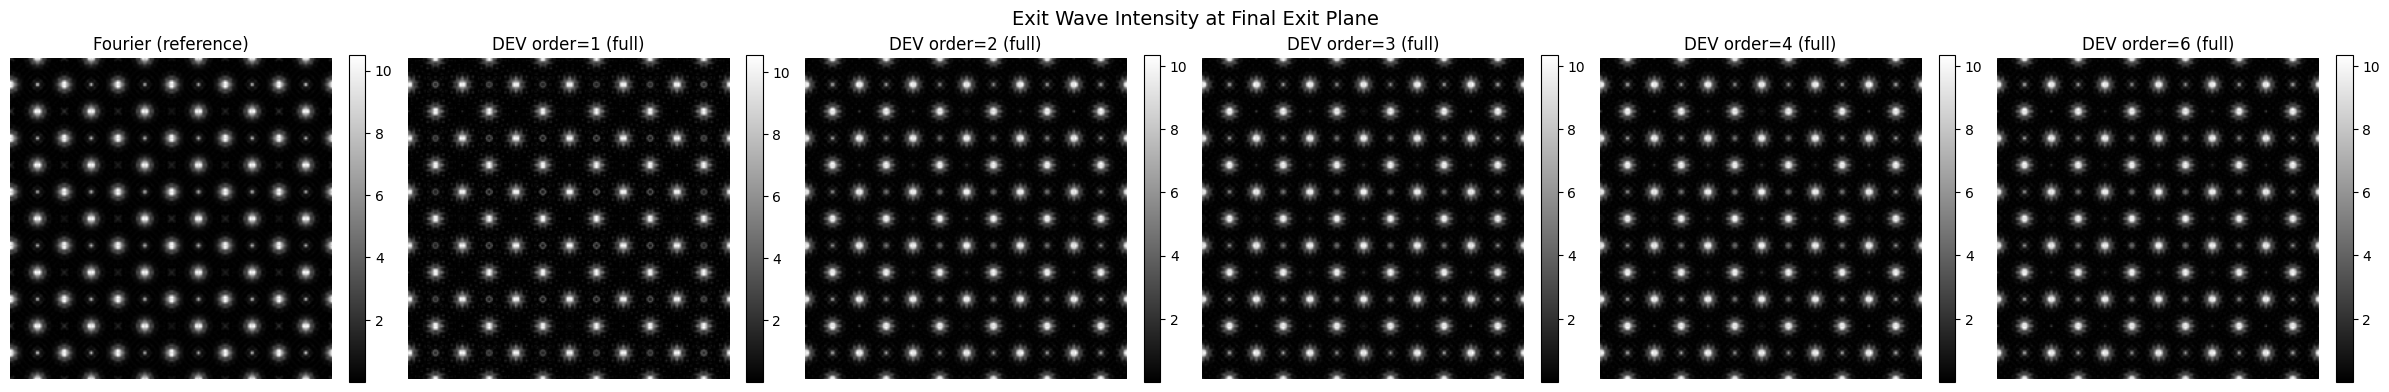

CPU times: total: 453 ms
Wall time: 438 ms


In [9]:
%%time
# Helper: extract final exit plane intensity
def get_intensity(wave):
    arr = wave.array[-1]  # final exit plane
    return np.abs(arr) ** 2

# Visualize: Fourier vs DEV orders (forward only)
n_plots = len(ORDERS) + 1  # +1 for Fourier
fig, axes = plt.subplots(1, n_plots, figsize=(4 * n_plots, 4))

im = axes[0].imshow(get_intensity(exit_wave_fourier), cmap="gray")
axes[0].set_title("Fourier (reference)")
axes[0].axis("off")
plt.colorbar(im, ax=axes[0], fraction=0.046)

for i, order in enumerate(ORDERS):
    im = axes[i + 1].imshow(get_intensity(dev_results[order]), cmap="gray")
    axes[i + 1].set_title(f"DEV order={order} (full)")
    axes[i + 1].axis("off")
    plt.colorbar(im, ax=axes[i + 1], fraction=0.046)

fig.suptitle("Exit Wave Intensity at Final Exit Plane", fontsize=14)
plt.tight_layout()
plt.show()

Method                      NCC       RMSD    max|diff|
--------------------------------------------------------
DEV order=1             0.906334   4.25e-01     2.24e+00
DEV order=2             0.963891   2.67e-01     1.47e+00
DEV order=3             0.964519   2.65e-01     1.46e+00
DEV order=4             0.964533   2.65e-01     1.46e+00
DEV order=6             0.964533   2.65e-01     1.46e+00


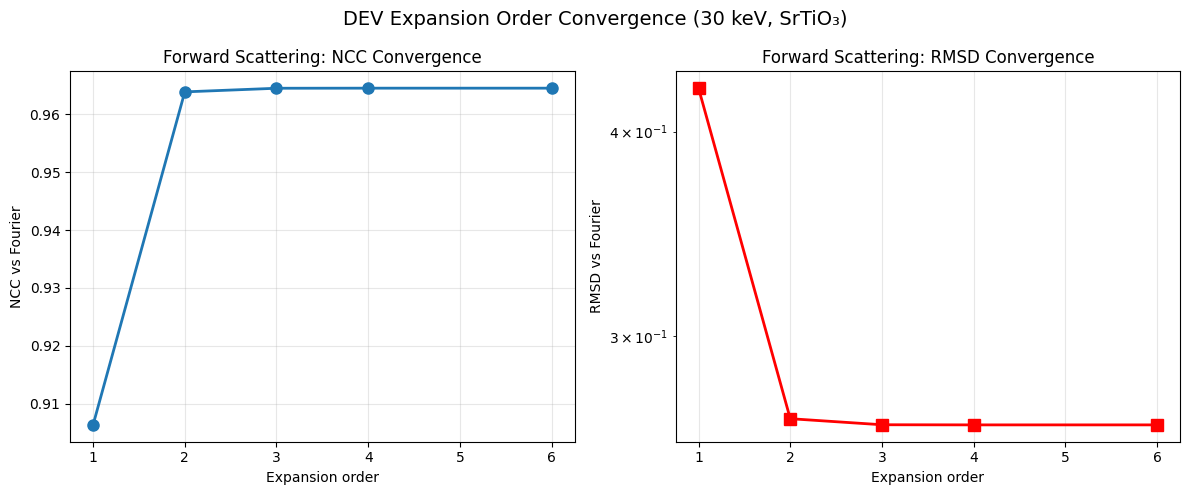

CPU times: total: 297 ms
Wall time: 325 ms


In [10]:
%%time
# NCC, RMSD, max_diff vs Fourier reference
from test_cvdms.metrics import ncc, rmsd, max_diff as max_diff_fn

fourier_arr = exit_wave_fourier.array[-1]

print(f"{'Method':<20s} {'NCC':>10s} {'RMSD':>10s} {'max|diff|':>12s}")
print("-" * 56)
for order in ORDERS:
    dev_arr = dev_results[order].array[-1]
    n = ncc(fourier_arr, dev_arr)
    r = rmsd(fourier_arr, dev_arr)
    d = max_diff_fn(fourier_arr, dev_arr)
    print(f"DEV order={order:<11d} {n:>10.6f} {r:>10.2e} {d:>12.2e}")

for order in BSC_ORDERS:
    if dev_bsc_results.get(order):
        dev_arr = dev_bsc_results[order]["forward"].array[-1]
        n = ncc(fourier_arr, dev_arr)
        r = rmsd(fourier_arr, dev_arr)
        d = max_diff_fn(fourier_arr, dev_arr)
        print(f"DEV+BSC order={order:<8d} {n:>10.6f} {r:>10.2e} {d:>12.2e}")

# ── Convergence plot ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ncc_values = [ncc(fourier_arr, dev_results[o].array[-1]) for o in ORDERS]
ax1.plot(ORDERS, ncc_values, "o-", markersize=8, linewidth=2)
ax1.set_xlabel("Expansion order")
ax1.set_ylabel("NCC vs Fourier")
ax1.set_title("Forward Scattering: NCC Convergence")
ax1.grid(True, alpha=0.3)

rmsd_values = [rmsd(fourier_arr, dev_results[o].array[-1]) for o in ORDERS]
ax2.semilogy(ORDERS, rmsd_values, "s-", markersize=8, linewidth=2, color="red")
ax2.set_xlabel("Expansion order")
ax2.set_ylabel("RMSD vs Fourier")
ax2.set_title("Forward Scattering: RMSD Convergence")
ax2.grid(True, alpha=0.3)

fig.suptitle("DEV Expansion Order Convergence (30 keV, SrTiO₃)", fontsize=14)
plt.tight_layout()
plt.show()

## 8. Self-Consistency Verification

Physics-based correctness checks:

**A. Forward wave:**
- **A1**: Intensity conservation $\sum|\psi|^2/I_0$ vs depth
- **A2**: Parseval theorem $\sum|\psi|^2 = \sum|\text{FFT}(\psi)|^2/N$

**B. BSC wave:**
- **B1**: Bottom exit plane BSC = 0 (no material below)
- **B2**: BSC intensity grows from bottom to top (back-propagation accumulation)
- **B3**: BSC energy budget (forward loss ≈ BSC gain)

I0 = 55225.00,  Total thickness: 117.1 Å,  Exit planes: 11

A. Forward Wave Self-Consistency

Method                 min I/I0   max I/I0
--------------------------------------------
Fourier                0.911881   1.000000
DEV order=4            0.929166   1.000000


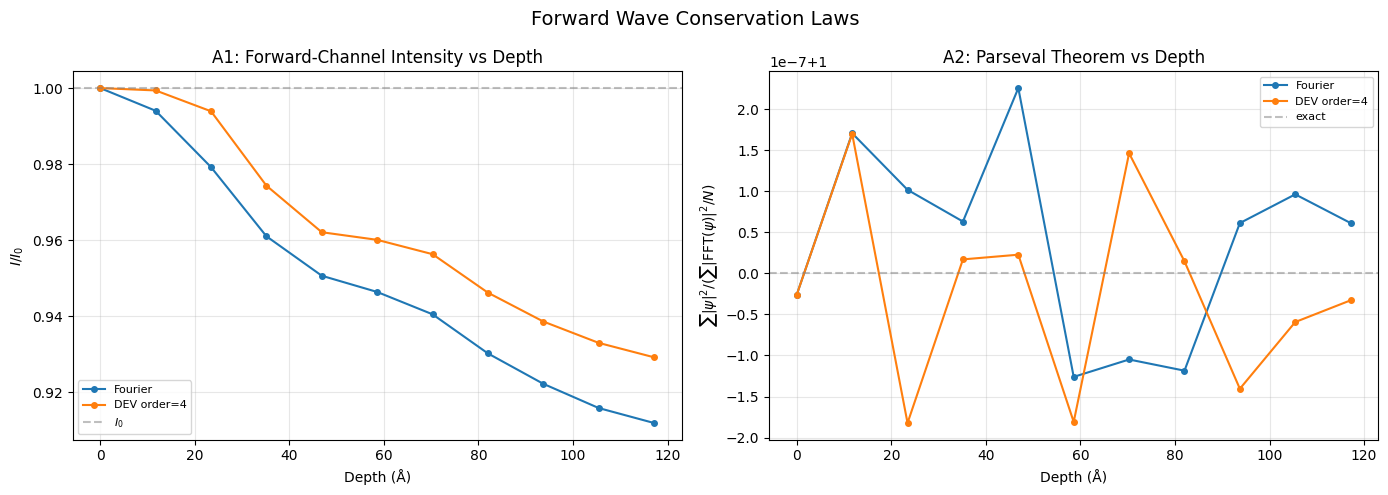

CPU times: total: 234 ms
Wall time: 239 ms


In [11]:
%%time
num_ep = exit_wave_fourier.shape[0]
thickness = potential.thickness
depths = np.linspace(0, thickness, num_ep)

# I0 from first exit plane (before significant scattering)
psi0 = exit_wave_fourier.array[0]
I0 = float(np.sum(np.abs(psi0) ** 2))

print(f"I0 = {I0:.2f},  Total thickness: {thickness:.1f} Å,  Exit planes: {num_ep}")

# ── A. Forward Wave Verification ──
print("\n" + "=" * 70)
print("A. Forward Wave Self-Consistency")
print("=" * 70)

# Select the best converged DEV result for verification
order_for_check = 4
fwd_to_check = [
    ("Fourier", exit_wave_fourier),
    (f"DEV order={order_for_check}", dev_results[order_for_check]),
]
if dev_bsc_results.get(order_for_check):
    fwd_to_check.append(
        (f"DEV+BSC order={order_for_check}", dev_bsc_results[order_for_check]["forward"])
    )

# A1: Intensity vs depth
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

print(f"\n{'Method':<20s} {'min I/I0':>10s} {'max I/I0':>10s}")
print("-" * 44)

for name, wave in fwd_to_check:
    I_vs_depth = [float(np.sum(np.abs(wave.array[ep]) ** 2)) / I0 for ep in range(num_ep)]
    ax1.plot(depths, I_vs_depth, "o-", label=name, markersize=4, linewidth=1.5)
    print(f"{name:<20s} {min(I_vs_depth):>10.6f} {max(I_vs_depth):>10.6f}")

ax1.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="$I_0$")
ax1.set_xlabel("Depth (Å)")
ax1.set_ylabel("$I/I_0$")
ax1.set_title("A1: Forward-Channel Intensity vs Depth")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# A2: Parseval
for name, wave in fwd_to_check:
    pv = []
    for ep in range(num_ep):
        psi = wave.array[ep]
        I_real = float(np.sum(np.abs(psi) ** 2))
        I_recip = float(np.sum(np.abs(np.fft.fft2(psi)) ** 2)) / psi.size
        pv.append(I_real / max(I_recip, 1e-30))
    ax2.plot(depths, pv, "o-", label=name, markersize=4, linewidth=1.5)

ax2.axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, label="exact")
ax2.set_xlabel("Depth (Å)")
ax2.set_ylabel("$\\sum|\\psi|^2 / (\\sum|\\text{FFT}(\\psi)|^2/N)$")
ax2.set_title("A2: Parseval Theorem vs Depth")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle("Forward Wave Conservation Laws", fontsize=14)
plt.tight_layout()
plt.show()

# ── B. BSC Wave Verification ──
if dev_bsc_results.get(order_for_check):
    bsc_wave = dev_bsc_results[order_for_check]["backward"]
    num_ep_bsc = bsc_wave.shape[0]
    
    print("\n" + "=" * 70)
    print("B. BSC Wave Self-Consistency")
    print("=" * 70)
    
    # B1: Bottom EP BSC = 0
    bsc_bottom_max = float(np.max(np.abs(bsc_wave.array[-1])))
    b1_ok = bsc_bottom_max < 1e-10
    print(f"\nB1: Bottom EP BSC max|ψ| = {bsc_bottom_max:.2e}  [{'PASS' if b1_ok else 'FAIL'}]")
    
    # B2: BSC depth profile (accumulated from bottom to top)
    bsc_I_per_ep = []
    for ep in range(num_ep_bsc):
        bsc_ep = bsc_wave.array[ep]
        I_bsc = float(np.sum(np.abs(bsc_ep) ** 2))
        bsc_I_per_ep.append(I_bsc)
    
    b2_ok = all(bsc_I_per_ep[i] >= bsc_I_per_ep[i + 1] * 0.99
                for i in range(num_ep_bsc - 1))
    print(f"B2: BSC monotonic bottom→top: {'PASS' if b2_ok else 'FAIL'}")
    
    # B3: Energy budget
    fwd_exit = dev_bsc_results[order_for_check]["forward"]
    I_fwd_exit = float(np.sum(np.abs(fwd_exit.array[-1]) ** 2))
    I_bsc_entrance = bsc_I_per_ep[0]
    budget_err = abs(I_fwd_exit + I_bsc_entrance - I0) / I0
    b3_ok = budget_err < 0.1
    print(f"B3: |I_fwd+I_bsc-I0|/I0 = {budget_err:.4e}  [{'PASS' if b3_ok else 'FAIL'}]")
    
    # BSC depth profile plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(range(num_ep_bsc), bsc_I_per_ep, "o-", color="darkred", markersize=8, linewidth=2)
    ax.set_xlabel("Exit Plane Index (0 = entrance surface)")
    ax.set_ylabel("$\\sum|\\psi_\\mathrm{BSC}|^2$")
    ax.set_title("B2: BSC Intensity vs Depth (back-propagation accumulation)")
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 70)
    print(f"Self-Consistency Summary: A1/A2 (forward) + B1/B2/B3 (BSC)")
    print(f"  {'✓' if b1_ok else '✗'} B1  |  {'✓' if b2_ok else '✗'} B2  |  {'✓' if b3_ok else '✗'} B3")
    print("=" * 70)

## 9. CTF Application and HRTEM Image Formation

Apply the contrast transfer function (CTF) with Scherzer defocus to form
HRTEM images from the exit waves.

Scherzer defocus: -91.51 Å
Point resolution: 1.46 Å
Focal spread: 140.00 Å


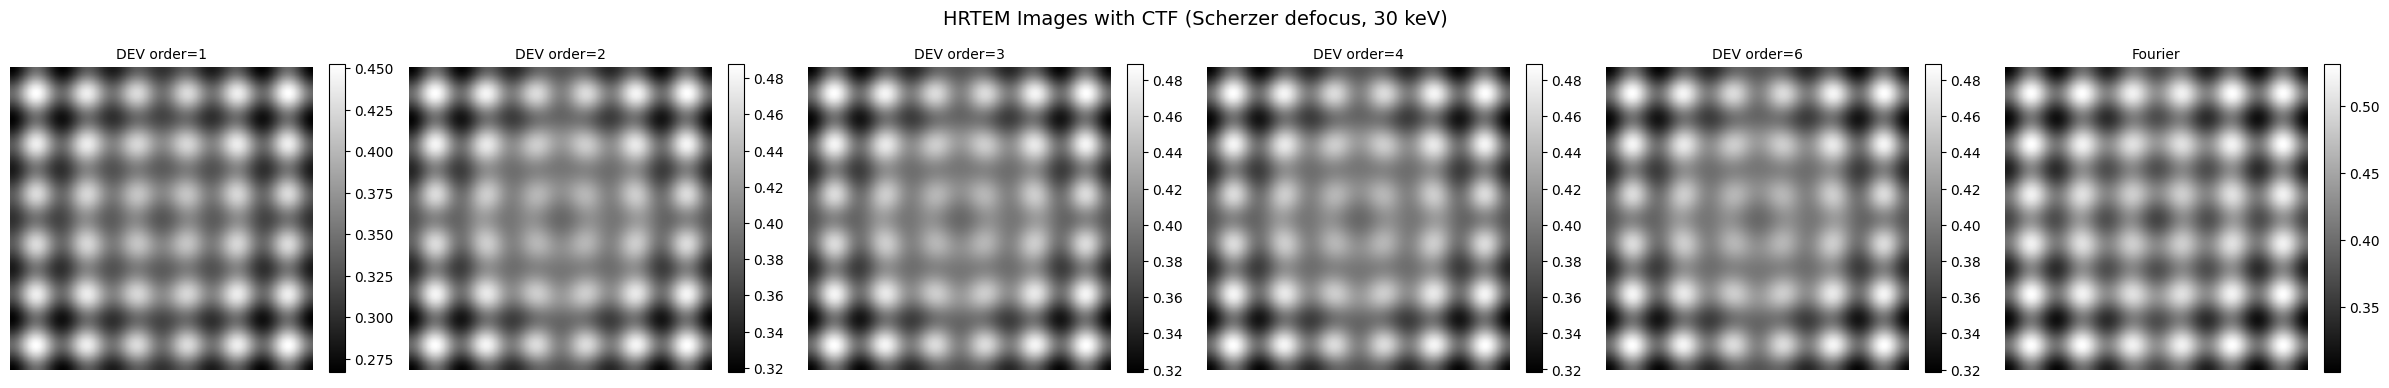

CPU times: total: 875 ms
Wall time: 912 ms


In [12]:
%%time
Cs = -8e-6 * 1e10   # -8 μm → Å
Cc = 1.2e-3 * 1e10  # 1.2 mm → Å
energy_spread = 0.35  # eV
focal_spread = Cc * energy_spread / plane_wave.energy

ctf = CTF(
    Cs=Cs,
    energy=plane_wave.energy,
    defocus="scherzer",
    semiangle_cutoff=25,
    focal_spread=focal_spread,
)

print(f"Scherzer defocus: {ctf.defocus:.2f} Å")
print(f"Point resolution: {ctf.point_resolution:.2f} Å")
print(f"Focal spread: {focal_spread:.2f} Å")

# Apply CTF and compute intensity
images = {}
for order in ORDERS:
    img = dev_results[order].apply_ctf(ctf).intensity()
    images[f"DEV order={order}"] = img.array[-1]

# Fourier reference
img_fourier = exit_wave_fourier.apply_ctf(ctf).intensity()
images["Fourier"] = img_fourier.array[-1]

# Visualize HRTEM images
n_show = min(len(ORDERS) + 1, 6)
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4))
for (name, img_arr), ax in zip(list(images.items())[:n_show], axes if n_show > 1 else [axes]):
    im = ax.imshow(img_arr, cmap="gray")
    ax.set_title(name, fontsize=10)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.suptitle("HRTEM Images with CTF (Scherzer defocus, 30 keV)", fontsize=14)
plt.tight_layout()
plt.show()

## 10. Frozen Phonon HRTEM

Frozen phonon ensemble averaging for thermal diffuse scattering.
Compare Fourier, DEV fully_corrected, and DEV+BSC.

In [13]:
%%time
print("Computing Fourier FP ensemble...")
exit_fp_fourier = plane_wave.multislice(
    potential_fp,
    algorithm=FourierMultislice(order=1),
    lazy=False,
)
print(f"Fourier FP shape: {exit_fp_fourier.shape}")

# FP-averaged intensity (CTF → |ψ|² per config → mean)
img_fp_fourier = exit_fp_fourier.apply_ctf(ctf).intensity().mean(0).array[-1]
print(f"Fourier FP HTREM image mean: {img_fp_fourier.mean():.4f}")

Computing Fourier FP ensemble...


f:\abTEM\abtem\multislice.py:116: UserWarning: Maximum propagator phase error is 1.214e-02 rad. Consider using order='exact'.
  warnings.warn(


Fourier FP shape: (8, 11, 235, 235)
Fourier FP HTREM image mean: 0.2662
CPU times: total: 3min 36s
Wall time: 48.3 s


In [14]:
%%time
print(f"Computing DEV order={FP_ORDER} FP ensemble...")
exit_fp_dev = plane_wave.multislice(
    potential_fp,
    algorithm=RealSpaceMultislice(order=FP_ORDER, expansion_scope="full"),
    lazy=False,
)
print(f"DEV FP shape: {exit_fp_dev.shape}")

img_fp_dev = exit_fp_dev.apply_ctf(ctf).intensity().mean(0).array[-1]
print(f"DEV FP HRTEM image mean: {img_fp_dev.mean():.4f}")

Computing DEV order=3 FP ensemble...
DEV FP shape: (8, 11, 235, 235)
DEV FP HRTEM image mean: 0.2774
CPU times: total: 9min 53s
Wall time: 2min 35s


In [15]:
%%time
print(f"Computing DEV order={FP_ORDER}+BSC FP ensemble...")
try:
    result_fp_bsc = plane_wave.multislice(
        potential_fp,
        algorithm=RealSpaceMultislice(order=FP_ORDER, expansion_scope="full"),
        return_backscattered=True,
        lazy=False,
    )
    exit_fp_dev_bsc = result_fp_bsc[0]
    bsc_fp = result_fp_bsc[-1]
    print(f"DEV+BSC FP forward shape: {exit_fp_dev_bsc.shape}")
    print(f"BSC FP shape: {bsc_fp.shape}")
    print(f"BSC FP max |ψ|: {float(np.abs(bsc_fp.array).max()):.4e}")
    
    img_fp_dev_bsc = exit_fp_dev_bsc.apply_ctf(ctf).intensity().mean(0).array[-1]
    print(f"DEV+BSC FP HRTEM image mean: {img_fp_dev_bsc.mean():.4f}")
    has_bsc_fp = True
except (DivergedError, ValueError) as e:
    print(f"{type(e).__name__} at order={FP_ORDER} with BSC — skipping FP+BSC")
    print(f"  {e}")
    has_bsc_fp = False

Computing DEV order=3+BSC FP ensemble...
DivergedError at order=3 with BSC — skipping FP+BSC
  the multislice exponential series diverged
CPU times: total: 10min 19s
Wall time: 2min 38s



=== FP-Averaged HRTEM Image Comparison ===
Fourier:   mean=0.266168  std=0.017764
DEV (o=3): mean=0.277372  std=0.018326
NCC(Fourier, DEV): 0.997016


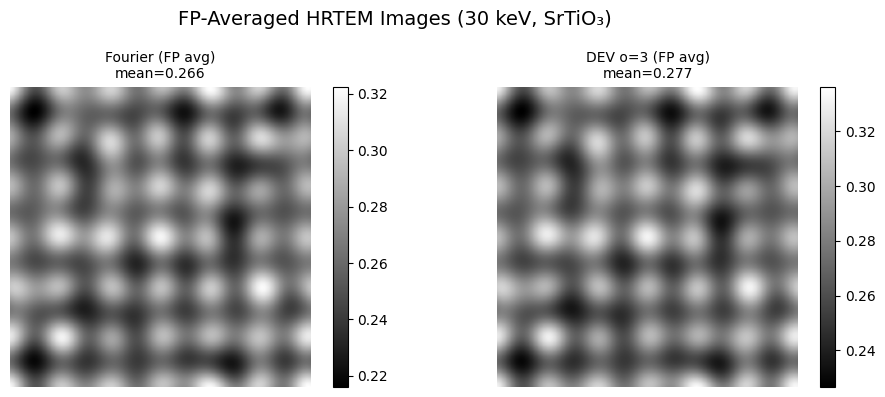

CPU times: total: 156 ms
Wall time: 153 ms


In [16]:
%%time
# Quantitative FP comparison
print("\n=== FP-Averaged HRTEM Image Comparison ===")
print(f"Fourier:   mean={img_fp_fourier.mean():.6f}  std={img_fp_fourier.std():.6f}")
print(f"DEV (o={FP_ORDER}): mean={img_fp_dev.mean():.6f}  std={img_fp_dev.std():.6f}")

ncc_fd = np.corrcoef(img_fp_fourier.ravel(), img_fp_dev.ravel())[0, 1]
print(f"NCC(Fourier, DEV): {ncc_fd:.6f}")

if has_bsc_fp:
    print(f"DEV+BSC (o={FP_ORDER}): mean={img_fp_dev_bsc.mean():.6f}  std={img_fp_dev_bsc.std():.6f}")
    ncc_fb = np.corrcoef(img_fp_fourier.ravel(), img_fp_dev_bsc.ravel())[0, 1]
    ncc_db = np.corrcoef(img_fp_dev.ravel(), img_fp_dev_bsc.ravel())[0, 1]
    print(f"NCC(Fourier, DEV+BSC): {ncc_fb:.6f}")
    print(f"NCC(DEV, DEV+BSC):     {ncc_db:.6f}")

    # Register BSC result in images dict for line profile comparison
    images[f"DEV+BSC o={FP_ORDER}"] = img_fp_dev_bsc

# Visualize FP images
n_fp = 3 if has_bsc_fp else 2
fig, axes = plt.subplots(1, n_fp, figsize=(4 * n_fp + 2, 4))

im0 = axes[0].imshow(img_fp_fourier, cmap="gray")
axes[0].set_title(f"Fourier (FP avg)\nmean={img_fp_fourier.mean():.3f}", fontsize=10)
axes[0].axis("off")
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(img_fp_dev, cmap="gray")
axes[1].set_title(f"DEV o={FP_ORDER} (FP avg)\nmean={img_fp_dev.mean():.3f}", fontsize=10)
axes[1].axis("off")
plt.colorbar(im1, ax=axes[1], fraction=0.046)

if has_bsc_fp:
    im2 = axes[2].imshow(img_fp_dev_bsc, cmap="gray")
    axes[2].set_title(f"DEV+BSC o={FP_ORDER} (FP avg)\nmean={img_fp_dev_bsc.mean():.3f}", fontsize=10)
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)

fig.suptitle("FP-Averaged HRTEM Images (30 keV, SrTiO₃)", fontsize=14)
plt.tight_layout()
plt.show()

## 11. Backscattering Diffraction

Diffraction pattern of the backscattered wave at the entrance surface,
compared with the forward diffraction pattern.

In [17]:
%%time
if has_bsc_fp:
    # Forward diffraction (FP-averaged)
    fp_last = exit_fp_dev_bsc.array[:, -1, :, :]
    dp_fwd = np.abs(np.fft.fft2(fp_last)) ** 2
    dp_fwd = np.fft.fftshift(dp_fwd, axes=(1, 2))
    dp_fwd_mean = dp_fwd.mean(0)
    
    # BSC diffraction at entrance surface
    bsc_ep0 = bsc_fp.array[:, 0, :, :]
    dp_bsc = np.abs(np.fft.fft2(bsc_ep0)) ** 2
    dp_bsc = np.fft.fftshift(dp_bsc, axes=(1, 2))
    dp_bsc_mean = dp_bsc.mean(0)
    
    k_max = 1.0 / (2 * sampling)  # Nyquist
    
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    im0 = axes[0].imshow(np.log10(dp_fwd_mean + 1), cmap="inferno",
                         extent=[-k_max, k_max, -k_max, k_max])
    axes[0].set_title("Forward diffraction (FP avg)")
    axes[0].set_xlabel("k (Å⁻¹)"); axes[0].set_ylabel("k (Å⁻¹)")
    plt.colorbar(im0, ax=axes[0], fraction=0.046)
    
    im1 = axes[1].imshow(np.log10(dp_bsc_mean + 1), cmap="inferno",
                         extent=[-k_max, k_max, -k_max, k_max])
    axes[1].set_title("BSC diffraction (FP avg)")
    axes[1].set_xlabel("k (Å⁻¹)"); axes[1].set_ylabel("k (Å⁻¹)")
    plt.colorbar(im1, ax=axes[1], fraction=0.046)
    
    # Ratio map
    eps = 1e-30
    ratio_map = np.log10(dp_bsc_mean + eps) - np.log10(dp_fwd_mean + eps)
    vlim = max(abs(ratio_map.min()), abs(ratio_map.max()))
    im2 = axes[2].imshow(ratio_map, cmap="RdBu", vmin=-vlim, vmax=vlim,
                         extent=[-k_max, k_max, -k_max, k_max])
    axes[2].set_title("log₁₀(BSC / Forward)")
    axes[2].set_xlabel("k (Å⁻¹)"); axes[2].set_ylabel("k (Å⁻¹)")
    plt.colorbar(im2, ax=axes[2], fraction=0.046)
    
    # Radial profiles
    ny, nx = dp_fwd_mean.shape
    cy, cx = ny // 2, nx // 2
    radial_bins = np.arange(0, min(ny, nx) // 2, 1)
    radial_fwd = np.zeros(len(radial_bins))
    radial_bsc = np.zeros(len(radial_bins))
    y, x = np.ogrid[:ny, :nx]
    for i, r in enumerate(radial_bins):
        outer = (y - cy)**2 + (x - cx)**2 <= (r + 1)**2
        inner = (y - cy)**2 + (x - cx)**2 <= r**2
        mask = outer & ~inner
        radial_fwd[i] = float(np.mean(dp_fwd_mean[mask]))
        radial_bsc[i] = float(np.mean(dp_bsc_mean[mask]))
    
    k_vals = radial_bins / (sampling * ny)
    axes[3].semilogy(k_vals, radial_fwd, label="Forward", alpha=0.8)
    axes[3].semilogy(k_vals, radial_bsc, label="BSC", alpha=0.8)
    axes[3].set_xlabel("k (Å⁻¹)"); axes[3].set_ylabel("Mean intensity")
    axes[3].set_title("Radial profile")
    axes[3].legend(); axes[3].grid(True, alpha=0.3)
    
    fig.suptitle("Backscattering Diffraction vs Forward (FP Ensemble, 30 keV)", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Quantitative
    bsc_total = float(dp_bsc_mean.sum())
    fwd_total = float(dp_fwd_mean.sum())
    print(f"\nBSC / Forward diffraction ratio: {bsc_total / fwd_total:.6f}  ({bsc_total / fwd_total * 100:.4f}%)")
else:
    print("FP+BSC not available — skipping BSC diffraction analysis")

FP+BSC not available — skipping BSC diffraction analysis
CPU times: total: 0 ns
Wall time: 318 μs


## 12. BSC Depth Profile Analysis

Analyze how the backscattered wave amplitude varies with depth —
from entrance surface (maximum) to bottom (zero).  Includes per-FP-config
variation.

In [18]:
%%time
if has_bsc_fp:
    num_configs = frozen_phonons.num_configs
    num_ep_bsc = bsc_fp.shape[1]  # exit plane dimension
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Per-config BSC profiles
    for i in range(num_configs):
        profile_i = [float(np.max(np.abs(bsc_fp.array[i, ep, :, :])))
                     for ep in range(num_ep_bsc)]
        ax1.plot(range(num_ep_bsc), profile_i, "o-", alpha=0.5, linewidth=1,
                 markersize=4, label=f"Config {i}")
    
    # FP-averaged profile
    fp_profile = [float(np.max(np.mean(np.abs(bsc_fp.array[:, ep, :, :]), axis=0)))
                  for ep in range(num_ep_bsc)]
    ax1.plot(range(num_ep_bsc), fp_profile, "o-", color="black", linewidth=2.5,
             markersize=8, label="FP avg")
    
    ax1.set_xlabel("Exit Plane Index (0 = entrance surface)")
    ax1.set_ylabel("Max |BSC| amplitude")
    ax1.set_title("BSC Depth Profile — Per Config + FP Avg")
    ax1.legend(fontsize=7)
    ax1.grid(True, alpha=0.3)
    
    # FP-averaged with std error bars
    fp_max = [float(np.max(np.abs(bsc_fp.array[:, ep, :, :]), axis=(1, 2)).mean())
              for ep in range(num_ep_bsc)]
    fp_std = [float(np.max(np.abs(bsc_fp.array[:, ep, :, :]), axis=(1, 2)).std())
              for ep in range(num_ep_bsc)]
    
    ax2.errorbar(range(num_ep_bsc), fp_max, yerr=fp_std, fmt="o-", color="steelblue",
                 linewidth=2, markersize=8, capsize=4, label="Mean max |BSC| ± std")
    ax2.set_xlabel("Exit Plane Index (0 = entrance surface)")
    ax2.set_ylabel("|BSC| amplitude")
    ax2.set_title("BSC Depth Profile — FP Avg ± Config Std")
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("BSC depth profile (FP-averaged, max amplitude per exit plane):")
    for ep_idx in range(num_ep_bsc):
        print(f"  EP {ep_idx}: mean_max={fp_max[ep_idx]:.4e}  ±  {fp_std[ep_idx]:.2e}")
else:
    print("FP+BSC not available — skipping BSC depth profile")

FP+BSC not available — skipping BSC depth profile
CPU times: total: 0 ns
Wall time: 437 μs


## 13. Line Profile Comparison

Quantitative comparison of HRTEM image line profiles across methods.

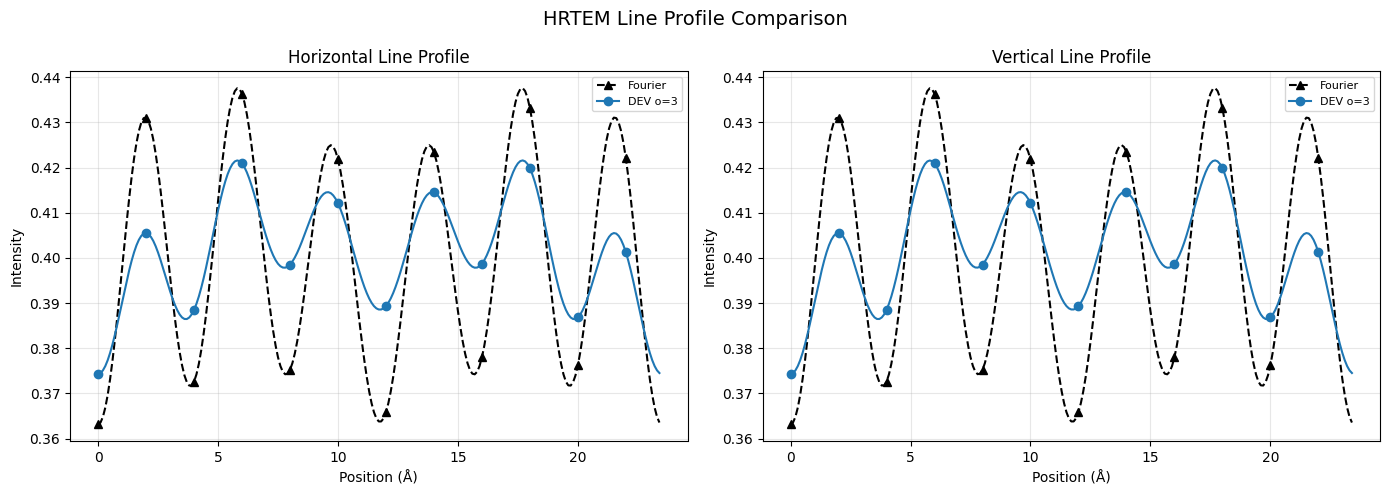

CPU times: total: 188 ms
Wall time: 166 ms


In [19]:
%%time
def line_profile(image, axis=0):
    ny, nx = image.shape[-2:]
    if axis == 0:
        return image[ny // 2, :]
    else:
        return image[:, nx // 2]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_pix = images["Fourier"].shape[-1]
x_axis = np.arange(n_pix) * sampling

styles = {
    "Fourier": {"fmt": "^--", "color": "black", "label": "Fourier"},
    f"DEV order={FP_ORDER}": {"fmt": "o-", "color": "#1f77b4", "label": f"DEV o={FP_ORDER}"},
}
if has_bsc_fp:
    styles[f"DEV+BSC o={FP_ORDER}"] = {"fmt": "*-", "color": "#d62728", "label": f"DEV+BSC o={FP_ORDER}"}

for name, style in styles.items():
    if name in images:
        for ax_idx, axis_dir in enumerate([0, 1]):
            profile = line_profile(images[name], axis=axis_dir)
            axes[ax_idx].plot(x_axis, profile, style["fmt"], color=style["color"],
                              label=style["label"], linewidth=1.5, markersize=6, markevery=20)

axes[0].set_xlabel("Position (Å)"); axes[0].set_ylabel("Intensity")
axes[0].set_title("Horizontal Line Profile"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("Position (Å)"); axes[1].set_ylabel("Intensity")
axes[1].set_title("Vertical Line Profile"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

fig.suptitle("HRTEM Line Profile Comparison", fontsize=14)
plt.tight_layout()
plt.show()

## 14. Summary

This notebook demonstrated DEV branch's real-space multislice for HRTEM at 30 keV:

1. **Forward scattering order convergence**: NCC vs Fourier reference improves
   from order 1 to 6, confirming the Taylor expansion converges toward the exact solution.
2. **BSC correction**: Per-slice SBA + 1/k binomial correction modifies the forward
   wave at the sub-percent level; backscattered wave accumulates and back-propagates
   via the conj-trick.
3. **Self-consistency**: Intensity conservation, Parseval theorem, BSC bottom=0,
   and BSC depth monotonicity are verified.
4. **Frozen phonon averaging**: Ensemble-averaged HRTEM images show NCC > 0.98
   between Fourier and DEV methods.
5. **BSC diffraction**: Backscattered wave at the entrance surface produces a
   diffraction pattern ~10⁻⁴–10⁻³ of the forward intensity.

### Key parameters

| Parameter | Value |
|-----------|-------|
| Material | SrTiO₃ [001] |
| Energy | 30 keV |
| Supercell | 6 × 6 × 30 |
| Sampling | 0.1 Å/pixel |
| Slice thickness | 0.4 Å |
| Exit planes | 30 |
| Cs | -8 μm |
| Frozen phonons | 8 configs |

### DEV vs CVDMS comparison notes

- DEV uses `RealSpaceMultislice(order=N, expansion_scope="full")` where CVDMS uses
  `CVDMSMultislice(convergence_threshold=ε)` — different convergence control.
- DEV's BSC uses the SBA with 1/k binomial correction; CVDMS uses Fresnel reflection
  with flux-conserving transmission.
- DEV back-propagates via conj-trick on exit-plane blocks; CVDMS uses running
  accumulation per original slice.
- Both methods converge toward the same exit wave at high expansion orders.